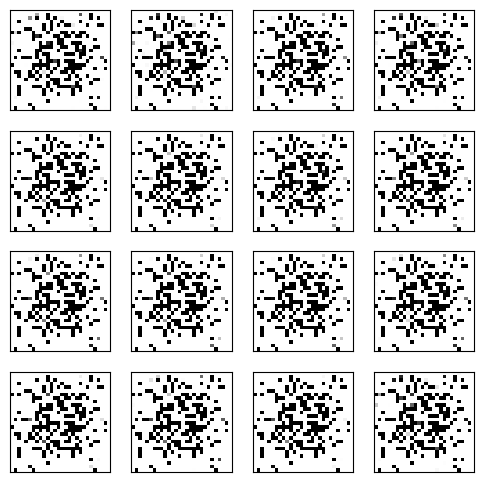

Epoch [22/200], Step[500/600], d_loss: 0.0000, g_loss: 84.6654, D(x): 1.00, D(G(z)): 0.00


KeyboardInterrupt: 

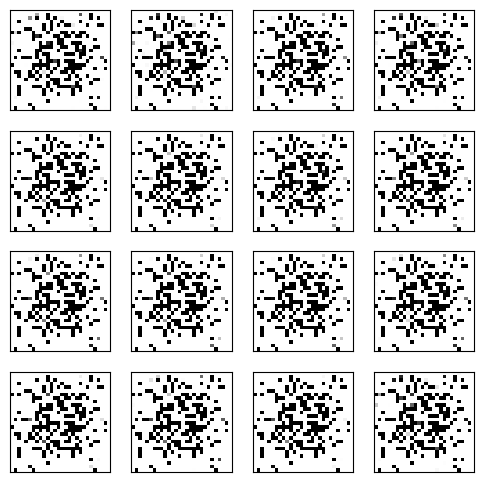

In [1]:
import itertools
import math
import time
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from IPython import display
from torch.autograd import Variable

seed = 67890
torch.manual_seed(seed)
np.random.seed(seed)

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = dsets.MNIST(root='./data/', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100, shuffle=True)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )
    
    def forward(self, x):
        out = self.model(x.view(x.size(0), 784))
        out = torch.sigmoid(out)
        out = out.view(out.size(0), -1)
        return out

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh()
        )
    
    def forward(self, x):
        x = x.view(x.size(0), 100)
        out = self.model(x)
        return out

discriminator = Discriminator().cuda()
generator = Generator().cuda()

criterion = nn.BCELoss()
lr = 0.0002
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lr)
g_optimizer = torch.optim.Adam(generator.parameters(), lr=lr)

def train_discriminator(discriminator, images, real_labels, fake_images, fake_labels):
    discriminator.zero_grad()
    outputs = discriminator(images)
    real_loss = criterion(outputs, real_labels)
    real_score = outputs
    
    outputs = discriminator(fake_images) 
    fake_loss = criterion(outputs, fake_labels)
    fake_score = outputs

    d_loss = real_loss + fake_loss
    d_loss.backward()
    d_optimizer.step()
    return d_loss, real_score, fake_score

def train_generator(generator, discriminator_outputs, real_labels):
    generator.zero_grad()
    g_loss = criterion(discriminator_outputs, real_labels)
    g_loss.backward()
    g_optimizer.step()
    return g_loss

# draw samples from the input distribution to inspect the generation on training 
num_test_samples = 16
test_noise = Variable(torch.randn(num_test_samples, 100).cuda())

# create figure for plotting
size_figure_grid = int(math.sqrt(num_test_samples))
fig, ax = plt.subplots(size_figure_grid, size_figure_grid, figsize=(6, 6))
for i, j in itertools.product(range(size_figure_grid), range(size_figure_grid)):
    ax[i,j].get_xaxis().set_visible(False)
    ax[i,j].get_yaxis().set_visible(False)

# set number of epochs and initialize figure counter
num_epochs = 200
num_batches = len(train_loader)
num_fig = 0


for epoch in range(num_epochs):
    for n, (images, _) in enumerate(train_loader):
        images = Variable(images.cuda())
        real_labels = Variable(torch.ones(images.size(0)).cuda())
        real_labels = Variable(torch.ones(images.size(0), 1).cuda())  # shape: [100, 1]

        # Sample from generator
        noise = Variable(torch.randn(images.size(0), 100).cuda())
        fake_images = generator(noise)
        fake_labels = Variable(torch.zeros(images.size(0), 1).cuda())  # shape: [100, 1]
        
        # Train the discriminator
        d_loss, real_score, fake_score = train_discriminator(discriminator, images, real_labels, fake_images, fake_labels)
        
        # Sample again from the generator and get output from discriminator
        noise = Variable(torch.randn(images.size(0), 100).cuda())
        fake_images = generator(noise)
        outputs = discriminator(fake_images)

        # Train the generator
        g_loss = train_generator(generator, outputs, real_labels)
        
        if (n+1) % 500 == 0:
            test_images = generator(test_noise)
            
            for k in range(num_test_samples):
                i = k//4
                j = k%4
                ax[i,j].cla()
                ax[i,j].imshow(test_images[k,:].data.cpu().numpy().reshape(28, 28), cmap='Greys')
            display.clear_output(wait=True)
            display.display(plt.gcf())
            
            plt.savefig('results/mnist-gan-%03d.png'%num_fig)
            num_fig += 1
            print('Epoch [%d/%d], Step[%d/%d], d_loss: %.4f, g_loss: %.4f, ' 
                  'D(x): %.2f, D(G(z)): %.2f' 
                  %(epoch + 1, num_epochs, n+1, num_batches, d_loss.item(), g_loss.item(),
                    real_score.data.mean(), fake_score.data.mean()))

In [2]:
import os
print("当前工作目录是：", os.getcwd())

当前工作目录是： C:\Users\FabingDuan


In [5]:
plt.savefig(f'D:/PRE2023 2025/mnist-gan-{num_fig:03d}.eps', dpi=600, bbox_inches='tight', pad_inches=0.1)

<Figure size 640x480 with 0 Axes>

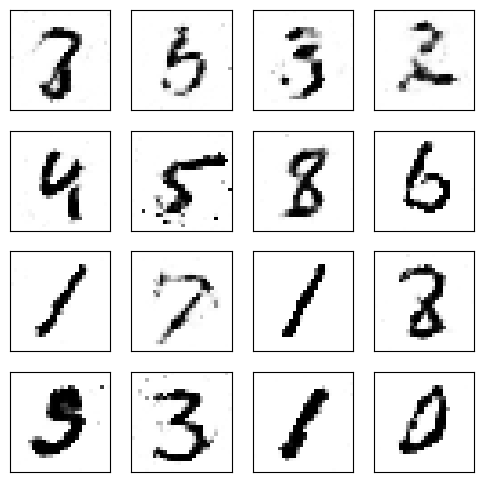

Epoch [100/100], Step[500/600], d_loss: 1.1966, g_loss: 0.8963, D(x): 0.56, D(G(z)): 0.43


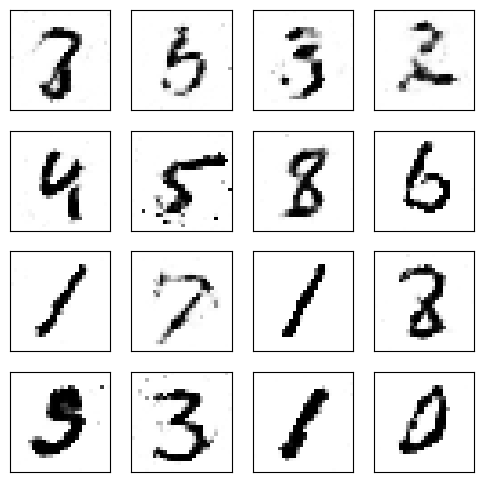

In [6]:
import itertools
import math
import time
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from IPython import display
from torch.autograd import Variable

seed = 67890
torch.manual_seed(seed)
np.random.seed(seed)

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = dsets.MNIST(root='./data/', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100, shuffle=True)

class Vsig(nn.Module):
    def __init__(self, init_sigma=0.2):  # 建议默认值就写 1.0（浮点数）
        super(Vsig, self).__init__()
        # 明确指定为 float32 类型，并包装成 nn.Parameter
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        # 加入一个防止 sigma 为 0 的 epsilon（可选但推荐）
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = 1 / (1 + torch.exp(-input /sigma_safe ))
        return output

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )
        self.vsig = Vsig()  # 建议使用较稳定的初始值，如1.0

    def forward(self, x):
        out = self.model(x.view(x.size(0), 784))
        out = self.vsig(out)  # 使用自定义激活函数
        out = out.view(out.size(0), -1)
        return out


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh()
        )
    
    def forward(self, x):
        x = x.view(x.size(0), 100)
        out = self.model(x)
        return out

discriminator = Discriminator().cuda()
generator = Generator().cuda()

criterion = nn.BCELoss()
lr = 0.0002
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lr)
g_optimizer = torch.optim.Adam(generator.parameters(), lr=lr)

def train_discriminator(discriminator, images, real_labels, fake_images, fake_labels):
    discriminator.zero_grad()
    outputs = discriminator(images)
    real_loss = criterion(outputs, real_labels)
    real_score = outputs
    
    outputs = discriminator(fake_images) 
    fake_loss = criterion(outputs, fake_labels)
    fake_score = outputs

    d_loss = real_loss + fake_loss
    d_loss.backward()
    d_optimizer.step()
    return d_loss, real_score, fake_score

def train_generator(generator, discriminator_outputs, real_labels):
    generator.zero_grad()
    g_loss = criterion(discriminator_outputs, real_labels)
    g_loss.backward()
    g_optimizer.step()
    return g_loss

# draw samples from the input distribution to inspect the generation on training 
num_test_samples = 16
test_noise = Variable(torch.randn(num_test_samples, 100).cuda())

# create figure for plotting
size_figure_grid = int(math.sqrt(num_test_samples))
fig, ax = plt.subplots(size_figure_grid, size_figure_grid, figsize=(6, 6))
for i, j in itertools.product(range(size_figure_grid), range(size_figure_grid)):
    ax[i,j].get_xaxis().set_visible(False)
    ax[i,j].get_yaxis().set_visible(False)

# set number of epochs and initialize figure counter
num_epochs = 100
num_batches = len(train_loader)
num_fig = 0


for epoch in range(num_epochs):
    for n, (images, _) in enumerate(train_loader):
        images = Variable(images.cuda())
        real_labels = Variable(torch.ones(images.size(0)).cuda())
        real_labels = Variable(torch.ones(images.size(0), 1).cuda())  # shape: [100, 1]

        # Sample from generator
        noise = Variable(torch.randn(images.size(0), 100).cuda())
        fake_images = generator(noise)
        fake_labels = Variable(torch.zeros(images.size(0), 1).cuda())  # shape: [100, 1]
        
        # Train the discriminator
        d_loss, real_score, fake_score = train_discriminator(discriminator, images, real_labels, fake_images, fake_labels)
        
        # Sample again from the generator and get output from discriminator
        noise = Variable(torch.randn(images.size(0), 100).cuda())
        fake_images = generator(noise)
        outputs = discriminator(fake_images)

        # Train the generator
        g_loss = train_generator(generator, outputs, real_labels)
        
        if (n+1) % 500 == 0:
            test_images = generator(test_noise)
            
            for k in range(num_test_samples):
                i = k//4
                j = k%4
                ax[i,j].cla()
                ax[i,j].imshow(test_images[k,:].data.cpu().numpy().reshape(28, 28), cmap='Greys')
            display.clear_output(wait=True)
            display.display(plt.gcf())
            
            plt.savefig('D:/PRE2023 2025/resultsig/mnist-gan-%03d.png'%num_fig)
            num_fig += 1
            print('Epoch [%d/%d], Step[%d/%d], d_loss: %.4f, g_loss: %.4f, ' 
                  'D(x): %.2f, D(G(z)): %.2f' 
                  %(epoch + 1, num_epochs, n+1, num_batches, d_loss.item(), g_loss.item(),
                    real_score.data.mean(), fake_score.data.mean()))

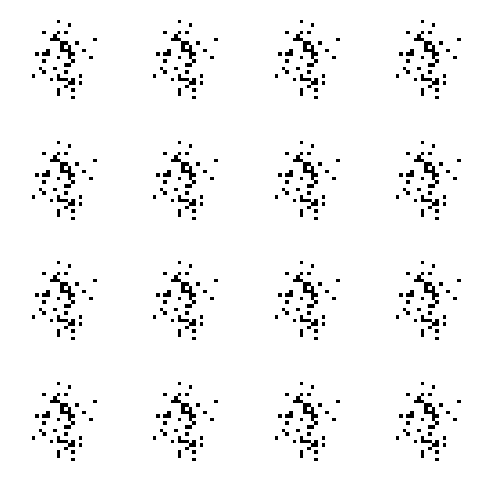

Epoch [200], Step [500], D_loss: 0.0000, G_loss: 27.7393, D(x): 1.00, D(G(z)): 0.00
Inception Score: 1.0000 ± 0.0000


d:\anaconda\envs\torch2\lib\site-packages\scipy\linalg\_matfuncs_sqrtm.py:209: RuntimeWarning: invalid value encountered in scalar divide
  arg2 = norm(X.dot(X) - A, 'fro')**2 / norm(A, 'fro')


FID: 0.0291
Mode Coverage: 1/10, KL: 2.3026
Class Counts: {3: 1000}
SSIM (avg over 100): 0.1754
Discriminator Accuracy - Real: 1.0000, Fake: 1.0000


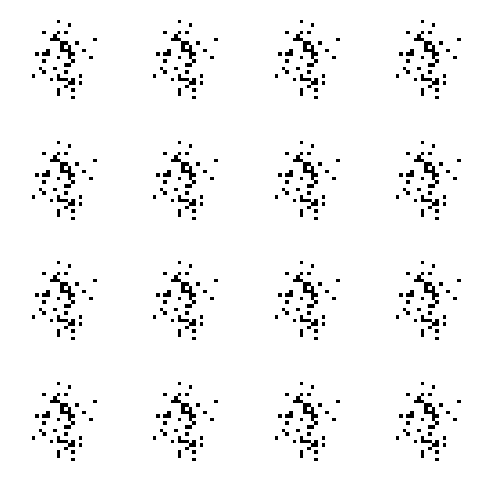

In [3]:
##############带评价指标的
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
from collections import Counter
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import math
import itertools
from scipy import linalg
import json

# 设置随机种子
seed = 67890
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 数据加载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = MNIST(root='./data/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)

# 判别器
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        out = self.model(x)
        return out.view(-1, 1)

# 生成器
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), 100)
        return self.model(x)

# 训练器
discriminator = Discriminator().to(device)
generator = Generator().to(device)
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002)
g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002)

def train_discriminator(real_images, real_labels, fake_images, fake_labels):
    discriminator.zero_grad()
    real_output = discriminator(real_images)
    real_loss = criterion(real_output, real_labels)

    fake_output = discriminator(fake_images)
    fake_loss = criterion(fake_output, fake_labels)

    d_loss = real_loss + fake_loss
    d_loss.backward()
    d_optimizer.step()
    return d_loss, real_output, fake_output

def train_generator(fake_images, real_labels):
    generator.zero_grad()
    output = discriminator(fake_images)
    g_loss = criterion(output, real_labels)
    g_loss.backward()
    g_optimizer.step()
    return g_loss

# 分类器（用于 IS、Mode）
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return F.softmax(self.fc2(x), dim=1)

def train_classifier(classifier, loader, epochs=3):
    classifier.train()
    optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            preds = classifier(x)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

# FID feature extractor
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

# 指标计算
def calculate_inception_score(images, classifier, splits=10):
    classifier.eval()
    with torch.no_grad():
        images = images.view(-1, 1, 28, 28)
        N = images.size(0)
        scores = []
        for i in range(splits):
            part = images[i * (N // splits):(i + 1) * (N // splits)]
            preds = classifier(part)
            kl = preds * (torch.log(preds + 1e-8) - torch.log(preds.mean(dim=0, keepdim=True) + 1e-8))
            scores.append(torch.exp(kl.sum(dim=1).mean()))
        return torch.stack(scores).mean().item(), torch.stack(scores).std().item()

def calculate_fid(real, fake):
    mu1, sigma1 = real.mean(0), np.cov(real.T)
    mu2, sigma2 = fake.mean(0), np.cov(fake.T)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

def calculate_mode_score(images, classifier):
    classifier.eval()
    with torch.no_grad():
        preds = classifier(images.view(-1, 1, 28, 28))
        labels = preds.argmax(dim=1).cpu().numpy()
        counts = Counter(labels)
        covered = len(counts)
        total = len(labels)
        kl = 0
        for i in range(10):
            p = counts.get(i, 0) / total
            if p > 0: kl += p * np.log(p / 0.1)
        return covered, kl, counts

def calculate_ssim(img1, img2):
    mu1, mu2 = img1.mean(), img2.mean()
    sigma1 = ((img1 - mu1) ** 2).mean()
    sigma2 = ((img2 - mu2) ** 2).mean()
    sigma12 = ((img1 - mu1) * (img2 - mu2)).mean()
    c1, c2 = 0.01**2, 0.03**2
    return ((2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)) / ((mu1**2 + mu2**2 + c1) * (sigma1 + sigma2 + c2))


# ========= GAN 训练 ==========
test_noise = torch.randn(16, 100).to(device)
fig, ax = plt.subplots(4, 4, figsize=(6, 6))
for i, j in itertools.product(range(4), range(4)):
    ax[i, j].axis('off')

for epoch in range(200):
    for n, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        real_labels = torch.ones(real_imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(real_imgs.size(0), 1).to(device)

        z = torch.randn(real_imgs.size(0), 100).to(device)
        fake_imgs = generator(z)

        d_loss, d_real, d_fake = train_discriminator(real_imgs, real_labels, fake_imgs.detach(), fake_labels)

        z = torch.randn(real_imgs.size(0), 100).to(device)
        fake_imgs = generator(z)
        g_loss = train_generator(fake_imgs, real_labels)

        if (n + 1) % 500 == 0:
            test_imgs = generator(test_noise).detach().cpu()
            for k in range(16):
                i, j = k // 4, k % 4
                ax[i, j].imshow(1-test_imgs[k].view(28, 28), cmap='gray')
            display.clear_output(wait=True)
            display.display(plt.gcf())
            
            plt.savefig(f"D:/PRE2025/results/epoch_{epoch}.png")
            print(f"Epoch [{epoch+1}], Step [{n+1}], D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f}, D(x): {d_real.mean().item():.2f}, D(G(z)): {d_fake.mean().item():.2f}")

# ========= 训练完成后评估 ==========

def evaluate_gan_quality(generator, discriminator, real_loader):
    generator.eval()
    discriminator.eval()
    
    # 1. 训练分类器（简单CNN）
    classifier = SimpleCNN().to(device)
    train_classifier(classifier, real_loader)
    
    # 2. 生成假图像和收集真实图像
    noise = torch.randn(1000, 100).to(device)
    with torch.no_grad():
        fake_images = generator(noise).view(-1, 1, 28, 28)

    # 从多个 batch 收集真实图像
    real_images = []
    for images, _ in real_loader:
        real_images.append(images)
        if sum([img.size(0) for img in real_images]) >= 1000:
            break
    real_images = torch.cat(real_images, dim=0)[:1000].to(device)

    # 3. Inception Score
    is_mean, is_std = calculate_inception_score(fake_images, classifier)
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    
    # 4. FID
    feat_ext = FeatureExtractor().to(device)
    real_feat = feat_ext(real_images).detach().cpu().numpy()
    fake_feat = feat_ext(fake_images).detach().cpu().numpy()
    fid = calculate_fid(real_feat, fake_feat)
    print(f"FID: {fid:.4f}")
    
    # 5. Mode Score
    modes, kl, counts = calculate_mode_score(fake_images, classifier)
    print(f"Mode Coverage: {modes}/10, KL: {kl:.4f}")
    print(f"Class Counts: {dict(counts)}")
    
    # 6. SSIM
    ssims = [calculate_ssim(fake_images[i].cpu(), real_images[i].cpu()).item() for i in range(100)]
    print(f"SSIM (avg over 100): {np.mean(ssims):.4f}")
    
    # 7. 判别器准确率
    with torch.no_grad():
        real_acc = (discriminator(real_images) > 0.5).float().mean().item()
        fake_acc = (discriminator(fake_images) < 0.5).float().mean().item()
    print(f"Discriminator Accuracy - Real: {real_acc:.4f}, Fake: {fake_acc:.4f}")
    
    # 8. 保存结果
    results = {
        'inception_score': [float(is_mean), float(is_std)],
        'fid': float(fid),
        'mode_coverage': int(modes),
        'kl_divergence': float(kl),
        'class_counts': {int(k): int(v) for k, v in dict(counts).items()},
        'avg_ssim': float(np.mean(ssims)),
        'discriminator_real_acc': float(real_acc),
        'discriminator_fake_acc': float(fake_acc)
    }

    import os
    os.makedirs("D:/PRE2025/results", exist_ok=True)
    with open("D:/PRE2025/resultsevaluation_results.json", "w") as f:
        import json
        json.dump(results, f, indent=2)


evaluate_gan_quality(generator, discriminator, train_loader)


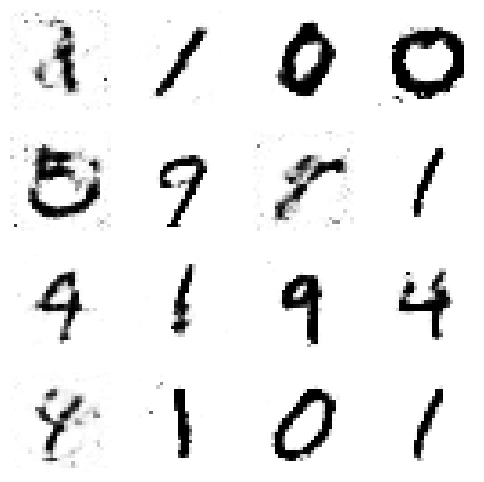

Epoch [200], Step [500], D_loss: 1.3855, G_loss: 0.7226, D(x): 0.56, D(G(z)): 0.52
Inception Score: 9.0034 ± 0.1798
FID: 0.0003
Mode Coverage: 10/10, KL: 0.0120
Class Counts: {5: 85, 6: 120, 4: 98, 2: 98, 7: 112, 0: 101, 9: 102, 8: 65, 1: 115, 3: 104}
SSIM (avg over 100): 0.2938
Discriminator Accuracy - Real: 0.4590, Fake: 0.7920


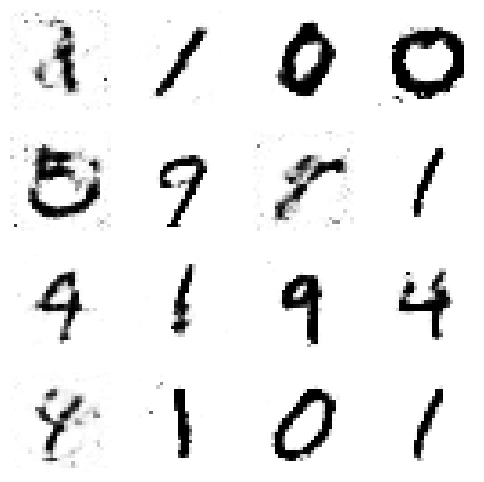

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
from collections import Counter
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import math
import itertools
from scipy import linalg
import json
from IPython import display  # 正确导入 display 模块

# 设置随机种子
seed = 67890
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 数据加载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = MNIST(root='./data/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)


class Vsig(nn.Module):
    def __init__(self, init_sigma=0.2):  # 建议默认值就写 1.0（浮点数）
        super(Vsig, self).__init__()
        # 明确指定为 float32 类型，并包装成 nn.Parameter
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        # 加入一个防止 sigma 为 0 的 epsilon（可选但推荐）
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = 1 / (1 + torch.exp(-input /sigma_safe ))
        return output
        
# 判别器
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            Vsig()
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        out = self.model(x)
        return out.view(-1, 1)

# 生成器
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), 100)
        return self.model(x)

# 训练器
discriminator = Discriminator().to(device)
generator = Generator().to(device)
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002)
g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002)

def train_discriminator(real_images, real_labels, fake_images, fake_labels):
    discriminator.zero_grad()
    real_output = discriminator(real_images)
    real_loss = criterion(real_output, real_labels)

    fake_output = discriminator(fake_images)
    fake_loss = criterion(fake_output, fake_labels)

    d_loss = real_loss + fake_loss
    d_loss.backward()
    d_optimizer.step()
    return d_loss, real_output, fake_output

def train_generator(fake_images, real_labels):
    generator.zero_grad()
    output = discriminator(fake_images)
    g_loss = criterion(output, real_labels)
    g_loss.backward()
    g_optimizer.step()
    return g_loss

# 分类器（用于 IS、Mode）
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return F.softmax(self.fc2(x), dim=1)

def train_classifier(classifier, loader, epochs=3):
    classifier.train()
    optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            preds = classifier(x)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

# FID feature extractor
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

# 指标计算
def calculate_inception_score(images, classifier, splits=10):
    classifier.eval()
    with torch.no_grad():
        images = images.view(-1, 1, 28, 28)
        N = images.size(0)
        scores = []
        for i in range(splits):
            part = images[i * (N // splits):(i + 1) * (N // splits)]
            preds = classifier(part)
            kl = preds * (torch.log(preds + 1e-8) - torch.log(preds.mean(dim=0, keepdim=True) + 1e-8))
            scores.append(torch.exp(kl.sum(dim=1).mean()))
        return torch.stack(scores).mean().item(), torch.stack(scores).std().item()

def calculate_fid(real, fake):
    mu1, sigma1 = real.mean(0), np.cov(real.T)
    mu2, sigma2 = fake.mean(0), np.cov(fake.T)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

def calculate_mode_score(images, classifier):
    classifier.eval()
    with torch.no_grad():
        preds = classifier(images.view(-1, 1, 28, 28))
        labels = preds.argmax(dim=1).cpu().numpy()
        counts = Counter(labels)
        covered = len(counts)
        total = len(labels)
        kl = 0
        for i in range(10):
            p = counts.get(i, 0) / total
            if p > 0: kl += p * np.log(p / 0.1)
        return covered, kl, counts

def calculate_ssim(img1, img2):
    mu1, mu2 = img1.mean(), img2.mean()
    sigma1 = ((img1 - mu1) ** 2).mean()
    sigma2 = ((img2 - mu2) ** 2).mean()
    sigma12 = ((img1 - mu1) * (img2 - mu2)).mean()
    c1, c2 = 0.01**2, 0.03**2
    return ((2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)) / ((mu1**2 + mu2**2 + c1) * (sigma1 + sigma2 + c2))


# ========= GAN 训练 ==========
test_noise = torch.randn(16, 100).to(device)
fig, ax = plt.subplots(4, 4, figsize=(6, 6))
for i, j in itertools.product(range(4), range(4)):
    ax[i, j].axis('off')

for epoch in range(200):
    for n, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        real_labels = torch.ones(real_imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(real_imgs.size(0), 1).to(device)

        z = torch.randn(real_imgs.size(0), 100).to(device)
        fake_imgs = generator(z)

        d_loss, d_real, d_fake = train_discriminator(real_imgs, real_labels, fake_imgs.detach(), fake_labels)

        z = torch.randn(real_imgs.size(0), 100).to(device)
        fake_imgs = generator(z)
        g_loss = train_generator(fake_imgs, real_labels)

        if (n + 1) % 500 == 0:
            test_imgs = generator(test_noise).detach().cpu()
            for k in range(16):
                i, j = k // 4, k % 4
                ax[i, j].imshow(1-test_imgs[k].view(28, 28), cmap='gray')
            display.clear_output(wait=True)
            display.display(plt.gcf())
            
            plt.savefig(f"D:/PRE2025/resultsvig/epoch_{epoch}.png")
            print(f"Epoch [{epoch+1}], Step [{n+1}], D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f}, D(x): {d_real.mean().item():.2f}, D(G(z)): {d_fake.mean().item():.2f}")

# ========= 训练完成后评估 ==========

def evaluate_gan_quality(generator, discriminator, real_loader):
    generator.eval()
    discriminator.eval()
    
    # 1. 训练分类器（简单CNN）
    classifier = SimpleCNN().to(device)
    train_classifier(classifier, real_loader)
    
    # 2. 生成假图像和收集真实图像
    noise = torch.randn(1000, 100).to(device)
    with torch.no_grad():
        fake_images = generator(noise).view(-1, 1, 28, 28)

    # 从多个 batch 收集真实图像
    real_images = []
    for images, _ in real_loader:
        real_images.append(images)
        if sum([img.size(0) for img in real_images]) >= 1000:
            break
    real_images = torch.cat(real_images, dim=0)[:1000].to(device)

    # 3. Inception Score
    is_mean, is_std = calculate_inception_score(fake_images, classifier)
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    
    # 4. FID
    feat_ext = FeatureExtractor().to(device)
    real_feat = feat_ext(real_images).detach().cpu().numpy()
    fake_feat = feat_ext(fake_images).detach().cpu().numpy()
    fid = calculate_fid(real_feat, fake_feat)
    print(f"FID: {fid:.4f}")
    
    # 5. Mode Score
    modes, kl, counts = calculate_mode_score(fake_images, classifier)
    print(f"Mode Coverage: {modes}/10, KL: {kl:.4f}")
    print(f"Class Counts: {dict(counts)}")
    
    # 6. SSIM
    ssims = [calculate_ssim(fake_images[i].cpu(), real_images[i].cpu()).item() for i in range(100)]
    print(f"SSIM (avg over 100): {np.mean(ssims):.4f}")
    
    # 7. 判别器准确率
    with torch.no_grad():
        real_acc = (discriminator(real_images) > 0.5).float().mean().item()
        fake_acc = (discriminator(fake_images) < 0.5).float().mean().item()
    print(f"Discriminator Accuracy - Real: {real_acc:.4f}, Fake: {fake_acc:.4f}")
    
    # 8. 保存结果
    results = {
        'inception_score': [float(is_mean), float(is_std)],
        'fid': float(fid),
        'mode_coverage': int(modes),
        'kl_divergence': float(kl),
        'class_counts': {int(k): int(v) for k, v in dict(counts).items()},
        'avg_ssim': float(np.mean(ssims)),
        'discriminator_real_acc': float(real_acc),
        'discriminator_fake_acc': float(fake_acc)
    }

    import os
    os.makedirs("D:/PRE2025/resultsvig", exist_ok=True)
    with open("D:/PRE2025/resultsvigevaluation_results.json", "w") as f:
        import json
        json.dump(results, f, indent=2)


evaluate_gan_quality(generator, discriminator, train_loader)

In [5]:
vig_layer = discriminator.model[-1]  # GEU 是 Sequential 的最后一层
print(f"Final learned sigma: {vig_layer.sigma.item():.4f}")

Final learned sigma: 2.8519


In [ ]:
#########GEU

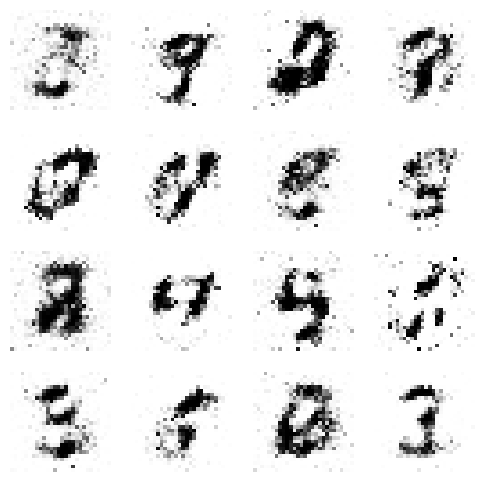

Epoch [200], Step [500], D_loss: 1.2062, G_loss: 0.8578, D(x): 0.60, D(G(z)): 0.45
Inception Score: 5.2918 ± 0.4560
FID: 0.0024
Mode Coverage: 10/10, KL: 0.3946
Class Counts: {3: 367, 2: 202, 4: 56, 8: 88, 7: 65, 5: 82, 1: 55, 0: 24, 9: 40, 6: 21}
SSIM (avg over 100): 0.2837
Discriminator Accuracy - Real: 0.7310, Fake: 0.9020


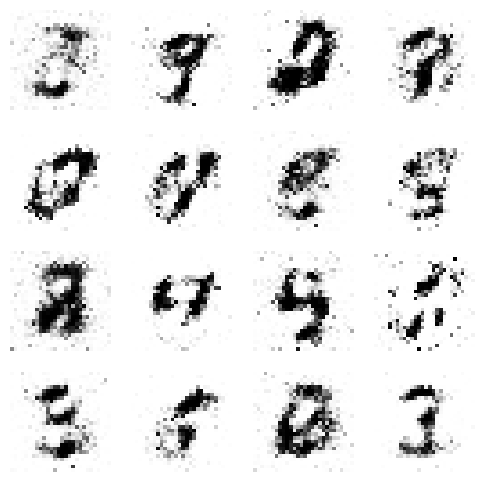

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
from collections import Counter
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import math
import itertools
from scipy import linalg
import json
from IPython import display  # 正确导入 display 模块

# 设置随机种子
seed = 67890
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 数据加载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = MNIST(root='./data/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)


class GEU(nn.Module):
    def __init__(self, init_sigma=1.0):
        super(GEU, self).__init__()
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        eps = 1e-6  # 避免除零
        sigma_safe = self.sigma + eps
        output = (1 + torch.erf(input / (torch.sqrt(torch.tensor(2.0)) * sigma_safe))) / 2
        return output
        
# 判别器
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            GEU()
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        out = self.model(x)
        return out.view(-1, 1)

# 生成器
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), 100)
        return self.model(x)

# 训练器
discriminator = Discriminator().to(device)
generator = Generator().to(device)
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002)
g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002)

def train_discriminator(real_images, real_labels, fake_images, fake_labels):
    discriminator.zero_grad()
    real_output = discriminator(real_images)
    real_loss = criterion(real_output, real_labels)

    fake_output = discriminator(fake_images)
    fake_loss = criterion(fake_output, fake_labels)

    d_loss = real_loss + fake_loss
    d_loss.backward()
    d_optimizer.step()
    return d_loss, real_output, fake_output

def train_generator(fake_images, real_labels):
    generator.zero_grad()
    output = discriminator(fake_images)
    g_loss = criterion(output, real_labels)
    g_loss.backward()
    g_optimizer.step()
    return g_loss

# 分类器（用于 IS、Mode）
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return F.softmax(self.fc2(x), dim=1)

def train_classifier(classifier, loader, epochs=3):
    classifier.train()
    optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            preds = classifier(x)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

# FID feature extractor
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

# 指标计算
def calculate_inception_score(images, classifier, splits=10):
    classifier.eval()
    with torch.no_grad():
        images = images.view(-1, 1, 28, 28)
        N = images.size(0)
        scores = []
        for i in range(splits):
            part = images[i * (N // splits):(i + 1) * (N // splits)]
            preds = classifier(part)
            kl = preds * (torch.log(preds + 1e-8) - torch.log(preds.mean(dim=0, keepdim=True) + 1e-8))
            scores.append(torch.exp(kl.sum(dim=1).mean()))
        return torch.stack(scores).mean().item(), torch.stack(scores).std().item()

def calculate_fid(real, fake):
    mu1, sigma1 = real.mean(0), np.cov(real.T)
    mu2, sigma2 = fake.mean(0), np.cov(fake.T)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

def calculate_mode_score(images, classifier):
    classifier.eval()
    with torch.no_grad():
        preds = classifier(images.view(-1, 1, 28, 28))
        labels = preds.argmax(dim=1).cpu().numpy()
        counts = Counter(labels)
        covered = len(counts)
        total = len(labels)
        kl = 0
        for i in range(10):
            p = counts.get(i, 0) / total
            if p > 0: kl += p * np.log(p / 0.1)
        return covered, kl, counts

def calculate_ssim(img1, img2):
    mu1, mu2 = img1.mean(), img2.mean()
    sigma1 = ((img1 - mu1) ** 2).mean()
    sigma2 = ((img2 - mu2) ** 2).mean()
    sigma12 = ((img1 - mu1) * (img2 - mu2)).mean()
    c1, c2 = 0.01**2, 0.03**2
    return ((2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)) / ((mu1**2 + mu2**2 + c1) * (sigma1 + sigma2 + c2))


# ========= GAN 训练 ==========
test_noise = torch.randn(16, 100).to(device)
fig, ax = plt.subplots(4, 4, figsize=(6, 6))
for i, j in itertools.product(range(4), range(4)):
    ax[i, j].axis('off')

for epoch in range(200):
    for n, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        real_labels = torch.ones(real_imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(real_imgs.size(0), 1).to(device)

        z = torch.randn(real_imgs.size(0), 100).to(device)
        fake_imgs = generator(z)

        d_loss, d_real, d_fake = train_discriminator(real_imgs, real_labels, fake_imgs.detach(), fake_labels)

        z = torch.randn(real_imgs.size(0), 100).to(device)
        fake_imgs = generator(z)
        g_loss = train_generator(fake_imgs, real_labels)

        if (n + 1) % 500 == 0:
            test_imgs = generator(test_noise).detach().cpu()
            for k in range(16):
                i, j = k // 4, k % 4
                ax[i, j].imshow(1-test_imgs[k].view(28, 28), cmap='gray')
            display.clear_output(wait=True)
            display.display(plt.gcf())
            
            plt.savefig(f"D:/PRE2025/resultsgeu/epoch_{epoch}.png")
            print(f"Epoch [{epoch+1}], Step [{n+1}], D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f}, D(x): {d_real.mean().item():.2f}, D(G(z)): {d_fake.mean().item():.2f}")

# ========= 训练完成后评估 ==========

def evaluate_gan_quality(generator, discriminator, real_loader):
    generator.eval()
    discriminator.eval()
    
    # 1. 训练分类器（简单CNN）
    classifier = SimpleCNN().to(device)
    train_classifier(classifier, real_loader)
    
    # 2. 生成假图像和收集真实图像
    noise = torch.randn(1000, 100).to(device)
    with torch.no_grad():
        fake_images = generator(noise).view(-1, 1, 28, 28)

    # 从多个 batch 收集真实图像
    real_images = []
    for images, _ in real_loader:
        real_images.append(images)
        if sum([img.size(0) for img in real_images]) >= 1000:
            break
    real_images = torch.cat(real_images, dim=0)[:1000].to(device)

    # 3. Inception Score
    is_mean, is_std = calculate_inception_score(fake_images, classifier)
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    
    # 4. FID
    feat_ext = FeatureExtractor().to(device)
    real_feat = feat_ext(real_images).detach().cpu().numpy()
    fake_feat = feat_ext(fake_images).detach().cpu().numpy()
    fid = calculate_fid(real_feat, fake_feat)
    print(f"FID: {fid:.4f}")
    
    # 5. Mode Score
    modes, kl, counts = calculate_mode_score(fake_images, classifier)
    print(f"Mode Coverage: {modes}/10, KL: {kl:.4f}")
    print(f"Class Counts: {dict(counts)}")
    
    # 6. SSIM
    ssims = [calculate_ssim(fake_images[i].cpu(), real_images[i].cpu()).item() for i in range(100)]
    print(f"SSIM (avg over 100): {np.mean(ssims):.4f}")
    
    # 7. 判别器准确率
    with torch.no_grad():
        real_acc = (discriminator(real_images) > 0.5).float().mean().item()
        fake_acc = (discriminator(fake_images) < 0.5).float().mean().item()
    print(f"Discriminator Accuracy - Real: {real_acc:.4f}, Fake: {fake_acc:.4f}")
    
    # 8. 保存结果
    results = {
        'inception_score': [float(is_mean), float(is_std)],
        'fid': float(fid),
        'mode_coverage': int(modes),
        'kl_divergence': float(kl),
        'class_counts': {int(k): int(v) for k, v in dict(counts).items()},
        'avg_ssim': float(np.mean(ssims)),
        'discriminator_real_acc': float(real_acc),
        'discriminator_fake_acc': float(fake_acc)
    }

    import os
    os.makedirs("D:/PRE2025/resultsgeu", exist_ok=True)
    with open("D:/PRE2025/resultsvigevaluation_results.json", "w") as f:
        import json
        json.dump(results, f, indent=2)


evaluate_gan_quality(generator, discriminator, train_loader)

In [7]:
geu_layer = discriminator.model[-1]  # GEU 是 Sequential 的最后一层
print(f"Final learned sigma: {geu_layer.sigma.item():.4f}")

Final learned sigma: 1.2549


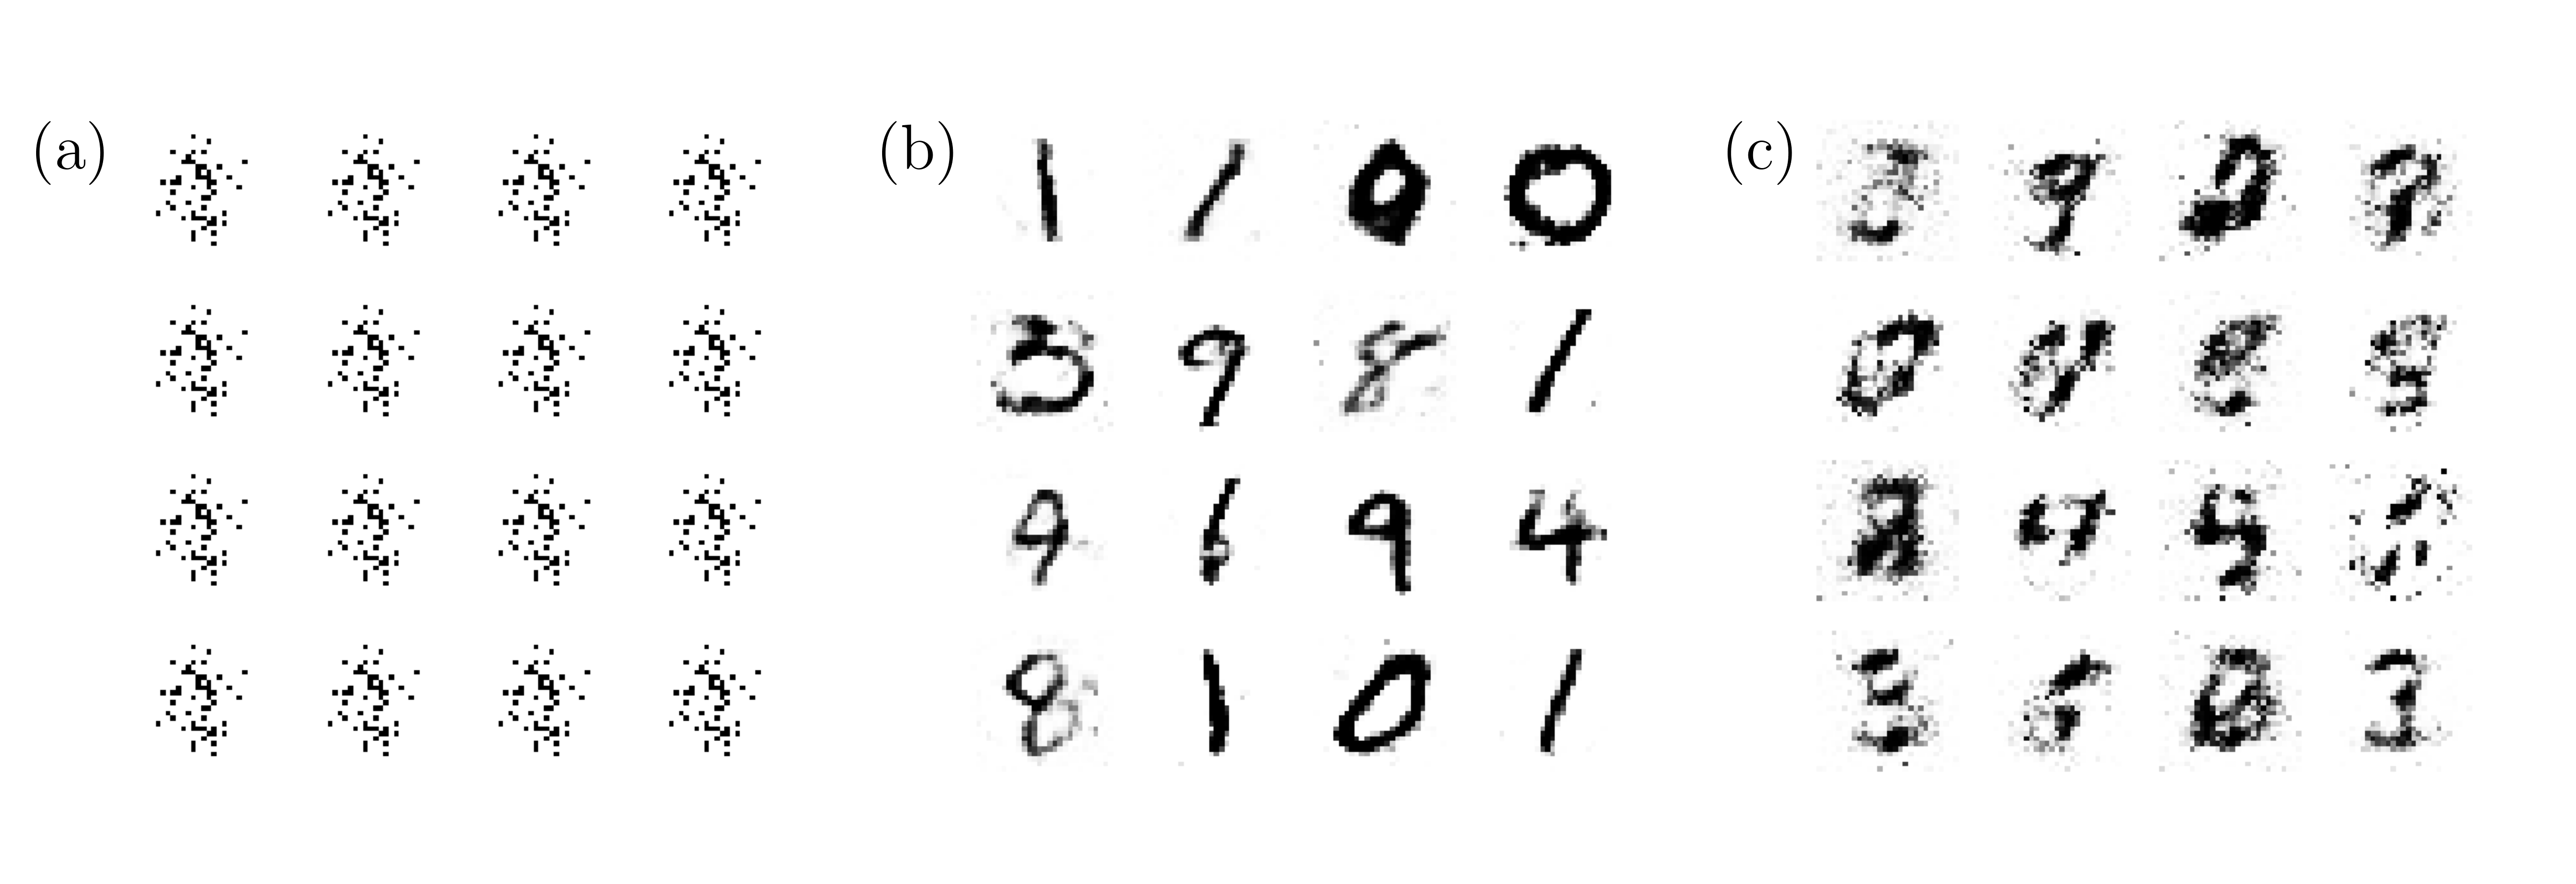

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib as mpl
import scienceplots

# 设置科学样式和字体
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False

# 图像路径
img_paths = [
    'D:/PRE2025/results/epoch_199.png',
    'D:/PRE2025/resultsvig/epoch_195.png',
    'D:/PRE2025/resultsgeu/epoch_199.png'
]

# 创建画布，使用 gridspec_kw 控制子图间距
fig, axes = plt.subplots(1, 3, figsize=(8.5, 3), gridspec_kw={'wspace': 0.0})

# 子图标签
labels = ['(a)', '(b)', '(c)']

# 显示每张图像
for i, ax in enumerate(axes):
    img = mpimg.imread(img_paths[i])
    ax.imshow(img)
    ax.axis('off')
    
    # 左上角标签，位置微调：y 从 0.95 改为 0.88 更居中
    ax.text(0.02, 0.88, labels[i], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')


# 保存为高分辨率 EPS 文件（去边框白边）
plt.savefig('D:/PRE2025/Fig5.eps', format='eps', dpi=600, bbox_inches='tight', pad_inches=0.0)

# 显示
plt.show()



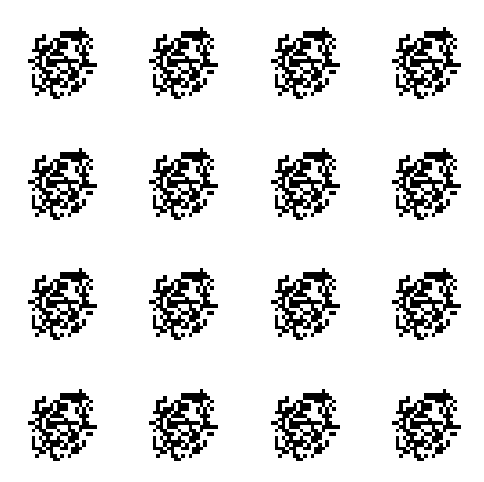

Epoch [10], Step [500], D_loss: 0.0000, G_loss: 23.2584, D(x): 1.00, D(G(z)): 0.00, Sigma: 0.9825


RuntimeError: CUDA error: CUBLAS_STATUS_EXECUTION_FAILED when calling `cublasSgemm( handle, opa, opb, m, n, k, &alpha, a, lda, b, ldb, &beta, c, ldc)`

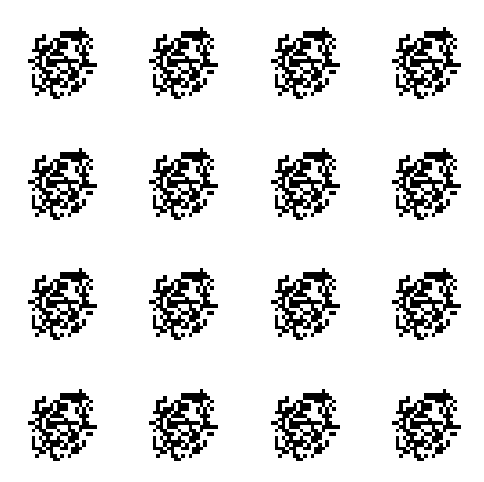

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
from collections import Counter
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import math
import itertools
from scipy import linalg
import json
from IPython import display  # 正确导入 display 模块

# 设置随机种子
seed = 67890
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 数据加载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = MNIST(root='./data/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)


class Vsig(nn.Module):
    def __init__(self, init_sigma=1.0):  # 建议默认值就写 1.0（浮点数）
        super(Vsig, self).__init__()
        # 明确指定为 float32 类型，并包装成 nn.Parameter
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        # 加入一个防止 sigma 为 0 的 epsilon（可选但推荐）
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = 1 / (1 + torch.exp(-input /sigma_safe ))
        return output
        
# 判别器
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            Vsig()
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        out = self.model(x)
        return out.view(-1, 1)

# 生成器
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), 100)
        return self.model(x)

# 训练器
discriminator = Discriminator().to(device)
generator = Generator().to(device)
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002)
g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002)

def train_discriminator(real_images, real_labels, fake_images, fake_labels):
    discriminator.zero_grad()
    real_output = discriminator(real_images)
    real_loss = criterion(real_output, real_labels)

    fake_output = discriminator(fake_images)
    fake_loss = criterion(fake_output, fake_labels)

    d_loss = real_loss + fake_loss
    d_loss.backward()
    d_optimizer.step()
    return d_loss, real_output, fake_output

def train_generator(fake_images, real_labels):
    generator.zero_grad()
    output = discriminator(fake_images)
    g_loss = criterion(output, real_labels)
    g_loss.backward()
    g_optimizer.step()
    return g_loss

# 分类器（用于 IS、Mode）
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return F.softmax(self.fc2(x), dim=1)

def train_classifier(classifier, loader, epochs=3):
    classifier.train()
    optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            preds = classifier(x)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

# FID feature extractor
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

# 指标计算
def calculate_inception_score(images, classifier, splits=10):
    classifier.eval()
    with torch.no_grad():
        images = images.view(-1, 1, 28, 28)
        N = images.size(0)
        scores = []
        for i in range(splits):
            part = images[i * (N // splits):(i + 1) * (N // splits)]
            preds = classifier(part)
            kl = preds * (torch.log(preds + 1e-8) - torch.log(preds.mean(dim=0, keepdim=True) + 1e-8))
            scores.append(torch.exp(kl.sum(dim=1).mean()))
        return torch.stack(scores).mean().item(), torch.stack(scores).std().item()

def calculate_fid(real, fake):
    mu1, sigma1 = real.mean(0), np.cov(real.T)
    mu2, sigma2 = fake.mean(0), np.cov(fake.T)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

def calculate_mode_score(images, classifier):
    classifier.eval()
    with torch.no_grad():
        preds = classifier(images.view(-1, 1, 28, 28))
        labels = preds.argmax(dim=1).cpu().numpy()
        counts = Counter(labels)
        covered = len(counts)
        total = len(labels)
        kl = 0
        for i in range(10):
            p = counts.get(i, 0) / total
            if p > 0: kl += p * np.log(p / 0.1)
        return covered, kl, counts

def calculate_ssim(img1, img2):
    mu1, mu2 = img1.mean(), img2.mean()
    sigma1 = ((img1 - mu1) ** 2).mean()
    sigma2 = ((img2 - mu2) ** 2).mean()
    sigma12 = ((img1 - mu1) * (img2 - mu2)).mean()
    c1, c2 = 0.01**2, 0.03**2
    return ((2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)) / ((mu1**2 + mu2**2 + c1) * (sigma1 + sigma2 + c2))


# ========= GAN 训练 ==========
test_noise = torch.randn(16, 100).to(device)
fig, ax = plt.subplots(4, 4, figsize=(6, 6))
for i, j in itertools.product(range(4), range(4)):
    ax[i, j].axis('off')

for epoch in range(200):
    for n, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        real_labels = torch.ones(real_imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(real_imgs.size(0), 1).to(device)

        z = torch.randn(real_imgs.size(0), 100).to(device)
        fake_imgs = generator(z)

        d_loss, d_real, d_fake = train_discriminator(real_imgs, real_labels, fake_imgs.detach(), fake_labels)

        z = torch.randn(real_imgs.size(0), 100).to(device)
        fake_imgs = generator(z)
        g_loss = train_generator(fake_imgs, real_labels)

        if (n + 1) % 500 == 0:
            test_imgs = generator(test_noise).detach().cpu()
            for k in range(16):
                i, j = k // 4, k % 4
                ax[i, j].imshow(1-test_imgs[k].view(28, 28), cmap='gray')
            display.clear_output(wait=True)
            display.display(plt.gcf())
            
            plt.savefig(f"D:/PRE2025/resultsvig1/epoch_{epoch}.png")
            sigma_value = discriminator.model[-1].sigma.item()
            print(f"Epoch [{epoch+1}], Step [{n+1}], D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f}, "
      f"D(x): {d_real.mean().item():.2f}, D(G(z)): {d_fake.mean().item():.2f}, "
      f"Sigma: {sigma_value:.4f}", flush=True)
            log_str = (f"Epoch [{epoch+1}], Step [{n+1}], D_loss: {d_loss.item():.4f}, "
           f"G_loss: {g_loss.item():.4f}, D(x): {d_real.mean().item():.2f}, "
           f"D(G(z)): {d_fake.mean().item():.2f}, Sigma: {sigma_value:.4f}")
            with open("D:/PRE2025/training_log-1.txt", "a") as f:
                f.write(log_str + "\n")

            #print(f"Epoch [{epoch+1}], Step [{n+1}], D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f}, D(x): {d_real.mean().item():.2f}, D(G(z)): {d_fake.mean().item():.2f}")

# ========= 训练完成后评估 ==========

def evaluate_gan_quality(generator, discriminator, real_loader):
    generator.eval()
    discriminator.eval()
    
    # 1. 训练分类器（简单CNN）
    classifier = SimpleCNN().to(device)
    train_classifier(classifier, real_loader)
    
    # 2. 生成假图像和收集真实图像
    noise = torch.randn(1000, 100).to(device)
    with torch.no_grad():
        fake_images = generator(noise).view(-1, 1, 28, 28)

    # 从多个 batch 收集真实图像
    real_images = []
    for images, _ in real_loader:
        real_images.append(images)
        if sum([img.size(0) for img in real_images]) >= 1000:
            break
    real_images = torch.cat(real_images, dim=0)[:1000].to(device)

    # 3. Inception Score
    is_mean, is_std = calculate_inception_score(fake_images, classifier)
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    
    # 4. FID
    feat_ext = FeatureExtractor().to(device)
    real_feat = feat_ext(real_images).detach().cpu().numpy()
    fake_feat = feat_ext(fake_images).detach().cpu().numpy()
    fid = calculate_fid(real_feat, fake_feat)
    print(f"FID: {fid:.4f}")
    
    # 5. Mode Score
    modes, kl, counts = calculate_mode_score(fake_images, classifier)
    print(f"Mode Coverage: {modes}/10, KL: {kl:.4f}")
    print(f"Class Counts: {dict(counts)}")
    
    # 6. SSIM
    ssims = [calculate_ssim(fake_images[i].cpu(), real_images[i].cpu()).item() for i in range(100)]
    print(f"SSIM (avg over 100): {np.mean(ssims):.4f}")
    
    # 7. 判别器准确率
    with torch.no_grad():
        real_acc = (discriminator(real_images) > 0.5).float().mean().item()
        fake_acc = (discriminator(fake_images) < 0.5).float().mean().item()
    print(f"Discriminator Accuracy - Real: {real_acc:.4f}, Fake: {fake_acc:.4f}")
    
    # 8. 保存结果
    results = {
        'inception_score': [float(is_mean), float(is_std)],
        'fid': float(fid),
        'mode_coverage': int(modes),
        'kl_divergence': float(kl),
        'class_counts': {int(k): int(v) for k, v in dict(counts).items()},
        'avg_ssim': float(np.mean(ssims)),
        'discriminator_real_acc': float(real_acc),
        'discriminator_fake_acc': float(fake_acc)
    }

    import os
    os.makedirs("D:/PRE2025/resultsvig1", exist_ok=True)
    with open("D:/PRE2025/resultsvig1evaluation_results.json", "w") as f:
        import json
        json.dump(results, f, indent=2)


evaluate_gan_quality(generator, discriminator, train_loader)

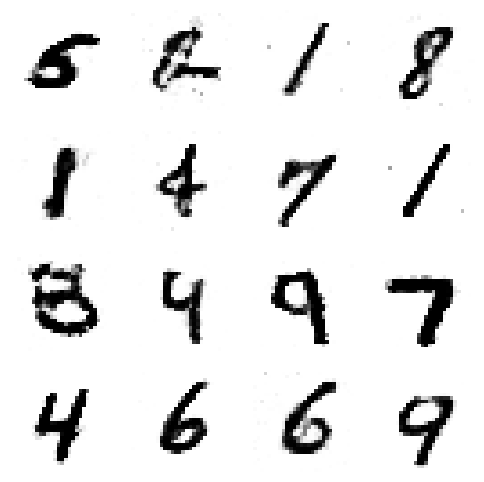

Epoch [200], Step [500], D_loss: 1.1837, G_loss: 0.9646, D(x): 0.59, D(G(z)): 0.43
Inception Score: 9.1116 ± 0.1585
FID: 0.0003
Mode Coverage: 10/10, KL: 0.0139
Class Counts: {0: 93, 8: 70, 5: 108, 1: 127, 2: 98, 7: 121, 9: 99, 6: 89, 3: 112, 4: 83}
SSIM (avg over 100): 0.2988
Discriminator Accuracy - Real: 0.5520, Fake: 0.7800


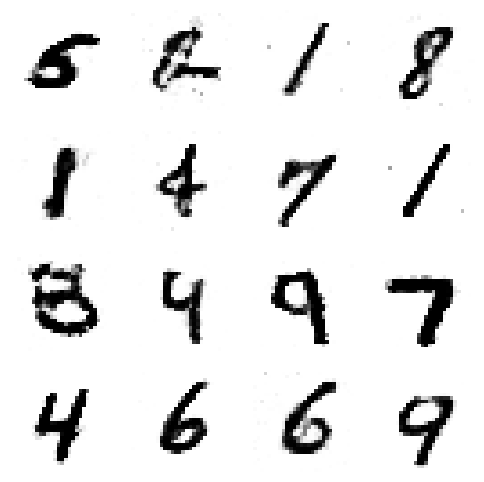

In [2]:
################Laplace
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
from collections import Counter
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import math
import itertools
from scipy import linalg
import json
from IPython import display  # 正确导入 display 模块

# 设置随机种子
seed = 67890
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 数据加载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = MNIST(root='./data/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)


class LaplaceCDF(nn.Module):
    def __init__(self, init_sigma=0.2):
        super(LaplaceCDF, self).__init__()
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = torch.where(
            input < 0,
            0.5 * torch.exp(input / sigma_safe),
            1 - 0.5 * torch.exp(-input / sigma_safe)
        )
        return output
        
# 判别器
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            LaplaceCDF()
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        out = self.model(x)
        return out.view(-1, 1)

# 生成器
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), 100)
        return self.model(x)

# 训练器
discriminator = Discriminator().to(device)
generator = Generator().to(device)
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002)
g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002)

def train_discriminator(real_images, real_labels, fake_images, fake_labels):
    discriminator.zero_grad()
    real_output = discriminator(real_images)
    real_loss = criterion(real_output, real_labels)

    fake_output = discriminator(fake_images)
    fake_loss = criterion(fake_output, fake_labels)

    d_loss = real_loss + fake_loss
    d_loss.backward()
    d_optimizer.step()
    return d_loss, real_output, fake_output

def train_generator(fake_images, real_labels):
    generator.zero_grad()
    output = discriminator(fake_images)
    g_loss = criterion(output, real_labels)
    g_loss.backward()
    g_optimizer.step()
    return g_loss

# 分类器（用于 IS、Mode）
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return F.softmax(self.fc2(x), dim=1)

def train_classifier(classifier, loader, epochs=3):
    classifier.train()
    optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            preds = classifier(x)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

# FID feature extractor
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

# 指标计算
def calculate_inception_score(images, classifier, splits=10):
    classifier.eval()
    with torch.no_grad():
        images = images.view(-1, 1, 28, 28)
        N = images.size(0)
        scores = []
        for i in range(splits):
            part = images[i * (N // splits):(i + 1) * (N // splits)]
            preds = classifier(part)
            kl = preds * (torch.log(preds + 1e-8) - torch.log(preds.mean(dim=0, keepdim=True) + 1e-8))
            scores.append(torch.exp(kl.sum(dim=1).mean()))
        return torch.stack(scores).mean().item(), torch.stack(scores).std().item()

def calculate_fid(real, fake):
    mu1, sigma1 = real.mean(0), np.cov(real.T)
    mu2, sigma2 = fake.mean(0), np.cov(fake.T)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

def calculate_mode_score(images, classifier):
    classifier.eval()
    with torch.no_grad():
        preds = classifier(images.view(-1, 1, 28, 28))
        labels = preds.argmax(dim=1).cpu().numpy()
        counts = Counter(labels)
        covered = len(counts)
        total = len(labels)
        kl = 0
        for i in range(10):
            p = counts.get(i, 0) / total
            if p > 0: kl += p * np.log(p / 0.1)
        return covered, kl, counts

def calculate_ssim(img1, img2):
    mu1, mu2 = img1.mean(), img2.mean()
    sigma1 = ((img1 - mu1) ** 2).mean()
    sigma2 = ((img2 - mu2) ** 2).mean()
    sigma12 = ((img1 - mu1) * (img2 - mu2)).mean()
    c1, c2 = 0.01**2, 0.03**2
    return ((2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)) / ((mu1**2 + mu2**2 + c1) * (sigma1 + sigma2 + c2))


# ========= GAN 训练 ==========
test_noise = torch.randn(16, 100).to(device)
fig, ax = plt.subplots(4, 4, figsize=(6, 6))
for i, j in itertools.product(range(4), range(4)):
    ax[i, j].axis('off')

for epoch in range(200):
    for n, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        real_labels = torch.ones(real_imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(real_imgs.size(0), 1).to(device)

        z = torch.randn(real_imgs.size(0), 100).to(device)
        fake_imgs = generator(z)

        d_loss, d_real, d_fake = train_discriminator(real_imgs, real_labels, fake_imgs.detach(), fake_labels)

        z = torch.randn(real_imgs.size(0), 100).to(device)
        fake_imgs = generator(z)
        g_loss = train_generator(fake_imgs, real_labels)

        if (n + 1) % 500 == 0:
            test_imgs = generator(test_noise).detach().cpu()
            for k in range(16):
                i, j = k // 4, k % 4
                ax[i, j].imshow(1-test_imgs[k].view(28, 28), cmap='gray')
            display.clear_output(wait=True)
            display.display(plt.gcf())
            
            plt.savefig(f"D:/PRE2025/resultslp/epoch_{epoch}.png")
            print(f"Epoch [{epoch+1}], Step [{n+1}], D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f}, D(x): {d_real.mean().item():.2f}, D(G(z)): {d_fake.mean().item():.2f}")

# ========= 训练完成后评估 ==========

def evaluate_gan_quality(generator, discriminator, real_loader):
    generator.eval()
    discriminator.eval()
    
    # 1. 训练分类器（简单CNN）
    classifier = SimpleCNN().to(device)
    train_classifier(classifier, real_loader)
    
    # 2. 生成假图像和收集真实图像
    noise = torch.randn(1000, 100).to(device)
    with torch.no_grad():
        fake_images = generator(noise).view(-1, 1, 28, 28)

    # 从多个 batch 收集真实图像
    real_images = []
    for images, _ in real_loader:
        real_images.append(images)
        if sum([img.size(0) for img in real_images]) >= 1000:
            break
    real_images = torch.cat(real_images, dim=0)[:1000].to(device)

    # 3. Inception Score
    is_mean, is_std = calculate_inception_score(fake_images, classifier)
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    
    # 4. FID
    feat_ext = FeatureExtractor().to(device)
    real_feat = feat_ext(real_images).detach().cpu().numpy()
    fake_feat = feat_ext(fake_images).detach().cpu().numpy()
    fid = calculate_fid(real_feat, fake_feat)
    print(f"FID: {fid:.4f}")
    
    # 5. Mode Score
    modes, kl, counts = calculate_mode_score(fake_images, classifier)
    print(f"Mode Coverage: {modes}/10, KL: {kl:.4f}")
    print(f"Class Counts: {dict(counts)}")
    
    # 6. SSIM
    ssims = [calculate_ssim(fake_images[i].cpu(), real_images[i].cpu()).item() for i in range(100)]
    print(f"SSIM (avg over 100): {np.mean(ssims):.4f}")
    
    # 7. 判别器准确率
    with torch.no_grad():
        real_acc = (discriminator(real_images) > 0.5).float().mean().item()
        fake_acc = (discriminator(fake_images) < 0.5).float().mean().item()
    print(f"Discriminator Accuracy - Real: {real_acc:.4f}, Fake: {fake_acc:.4f}")
    
    # 8. 保存结果
    results = {
        'inception_score': [float(is_mean), float(is_std)],
        'fid': float(fid),
        'mode_coverage': int(modes),
        'kl_divergence': float(kl),
        'class_counts': {int(k): int(v) for k, v in dict(counts).items()},
        'avg_ssim': float(np.mean(ssims)),
        'discriminator_real_acc': float(real_acc),
        'discriminator_fake_acc': float(fake_acc)
    }

    import os
    os.makedirs("D:/PRE2025/resultslp", exist_ok=True)
    with open("D:/PRE2025/resultslpevaluation_results.json", "w") as f:
        import json
        json.dump(results, f, indent=2)


evaluate_gan_quality(generator, discriminator, train_loader)

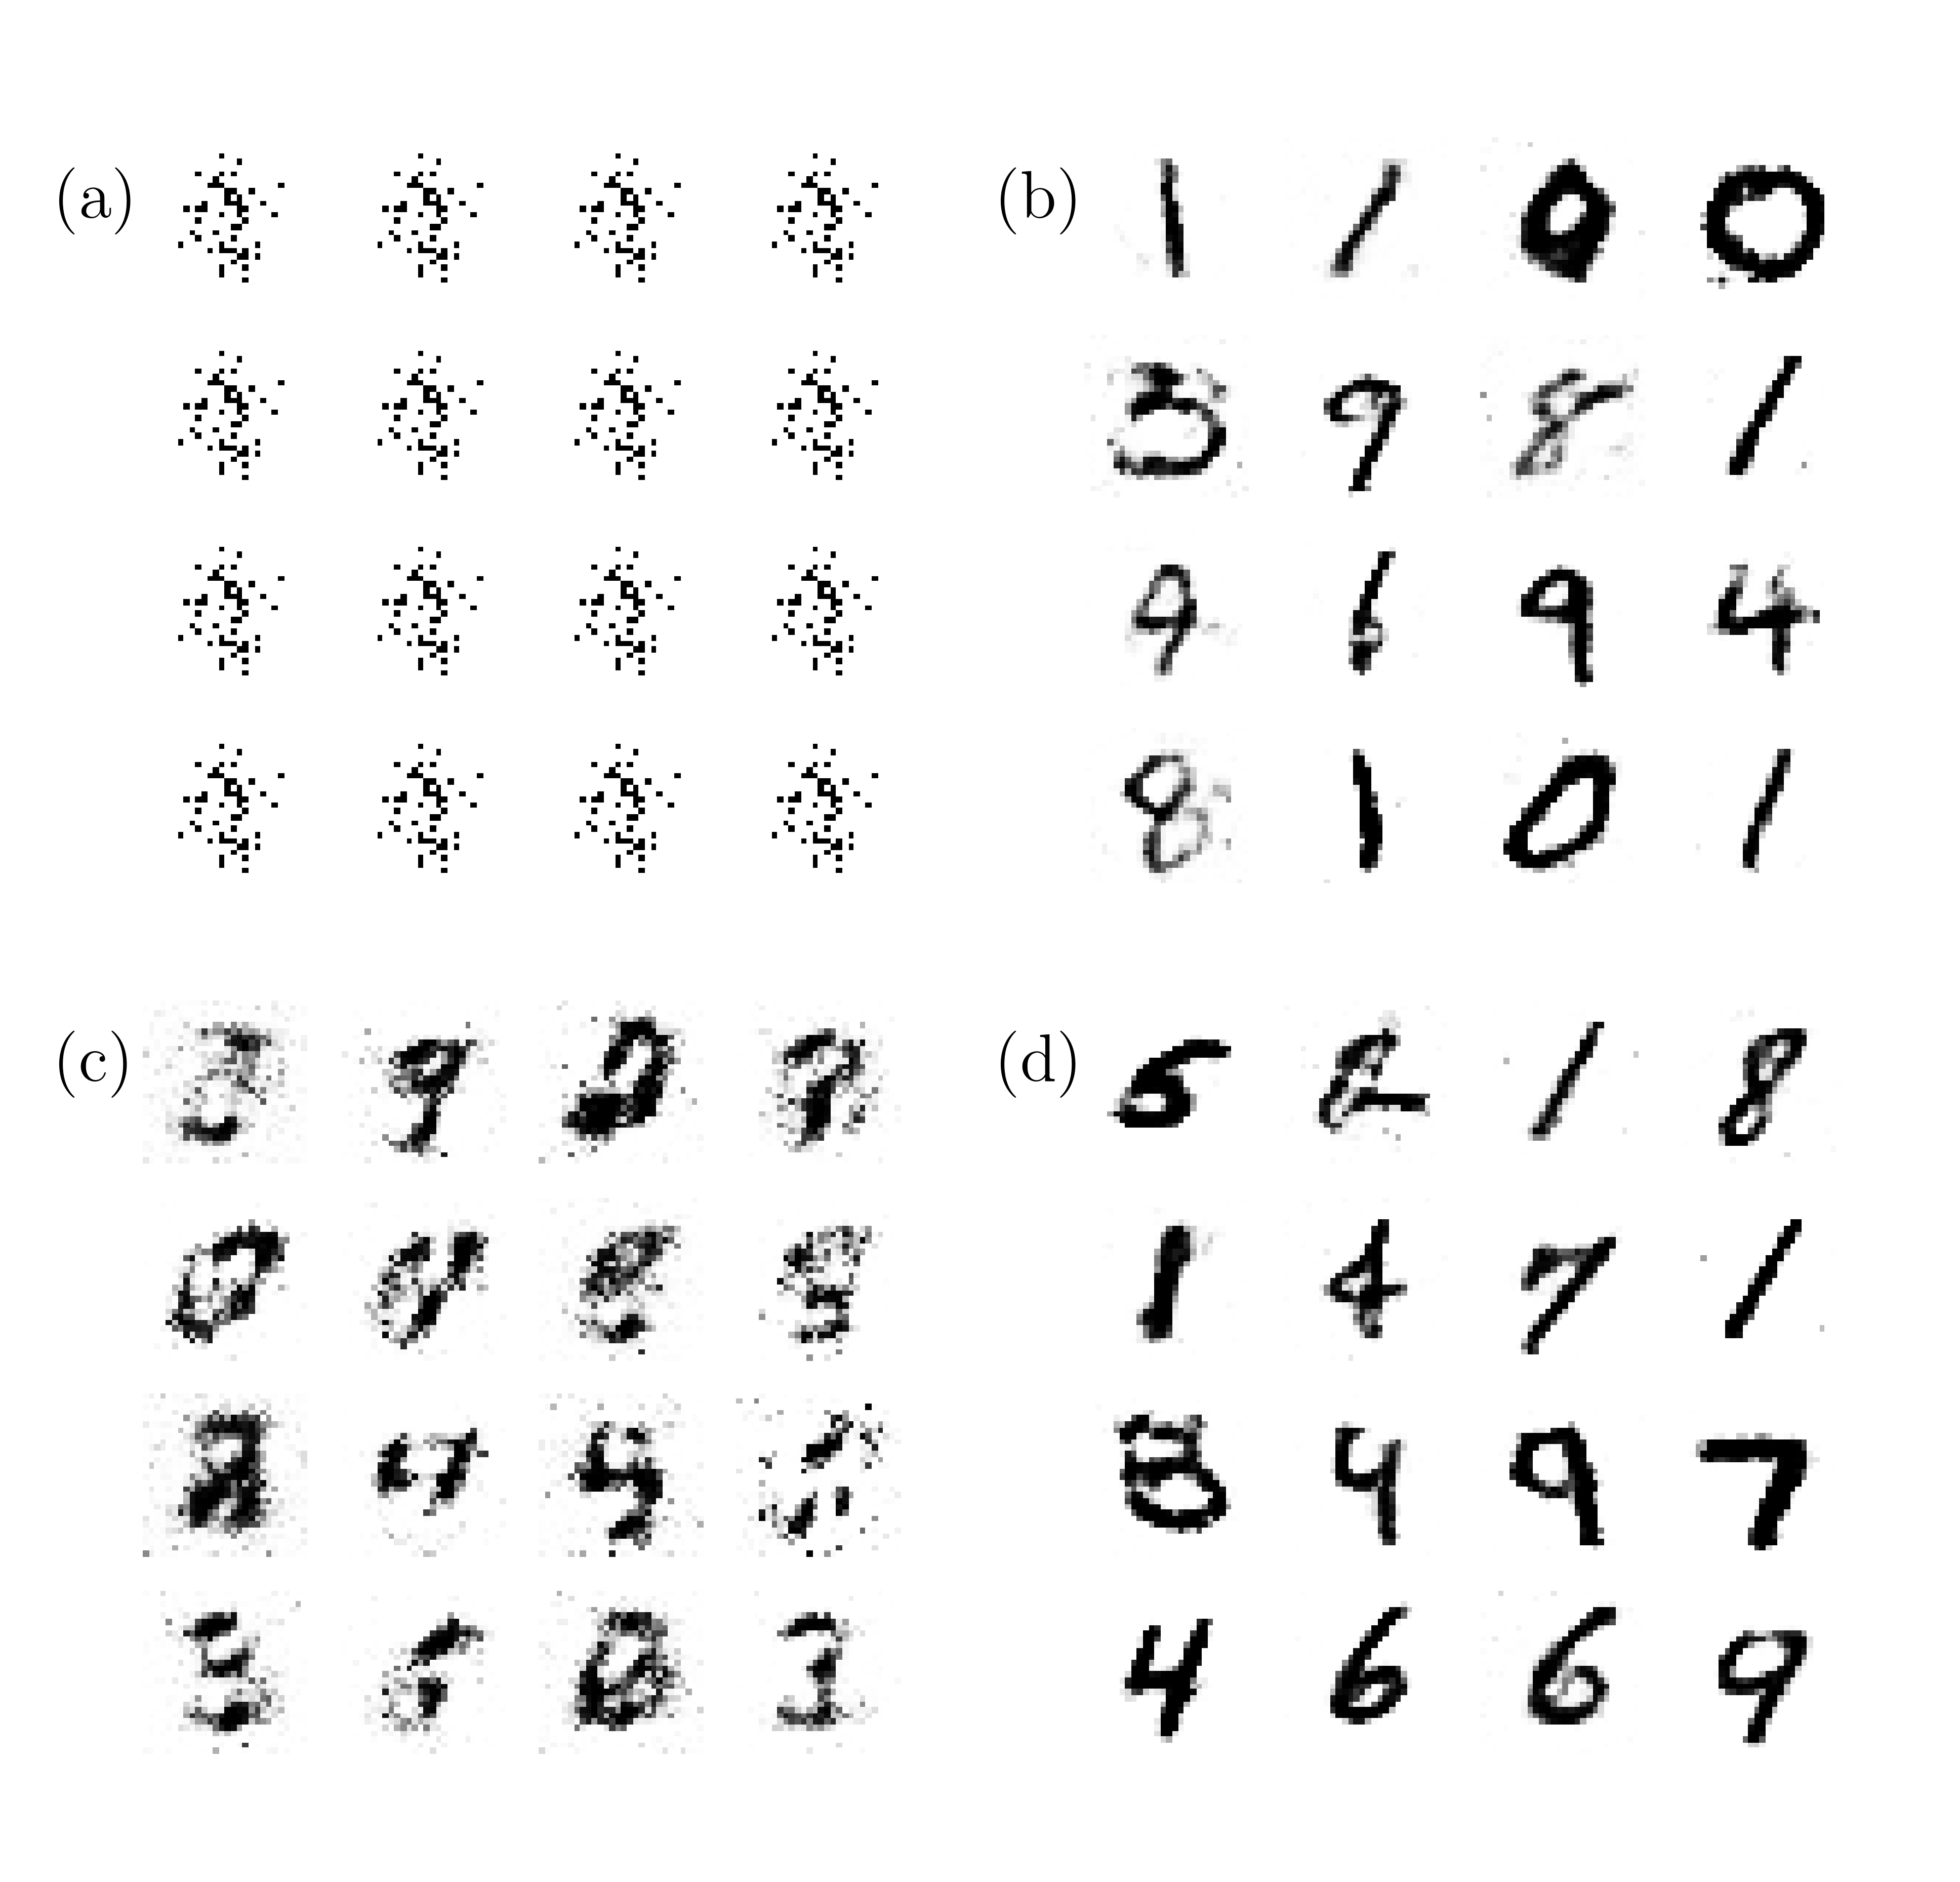

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib as mpl
import scienceplots

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False

img_paths = [
    'D:/PRE2025/results/epoch_199.png',
    'D:/PRE2025/resultsvig/epoch_195.png',
    'D:/PRE2025/resultsgeu/epoch_199.png',
    'D:/PRE2025/resultslp/epoch_199.png'
]

# 创建更紧凑的子图布局
fig, axes = plt.subplots(2, 2, figsize=(6.2, 4.5))

# 调整子图间距，使用负值进一步减少间距
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, 
                   wspace=-0.4, hspace=-0.1)

labels = ['(a)', '(b)', '(c)', '(d)']
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = mpimg.imread(img_paths[i])
    ax.imshow(img, extent=[0, 1, 0, 1])  # 标准化图片范围
    ax.axis('off')
    
    # 设置轴的边距为0
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.margins(0)
    
    # 添加标签
    ax.text(0.04, 0.85, labels[i], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

# 进一步减少图片间距
for ax in axes:
    ax.set_position(ax.get_position().shrunk(1.02, 1.02))

# 保存时使用更严格的边距控制
plt.savefig('D:/PRE2025/Fig5.eps', format='eps', dpi=800,
            bbox_inches='tight', pad_inches=0.0, facecolor='white')

plt.show()